   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

0: 352x640 (no detections), 328.1ms
Speed: 13.8ms preprocess, 328.1ms inference, 17.4ms postprocess per image at shape (1, 3, 352, 640)


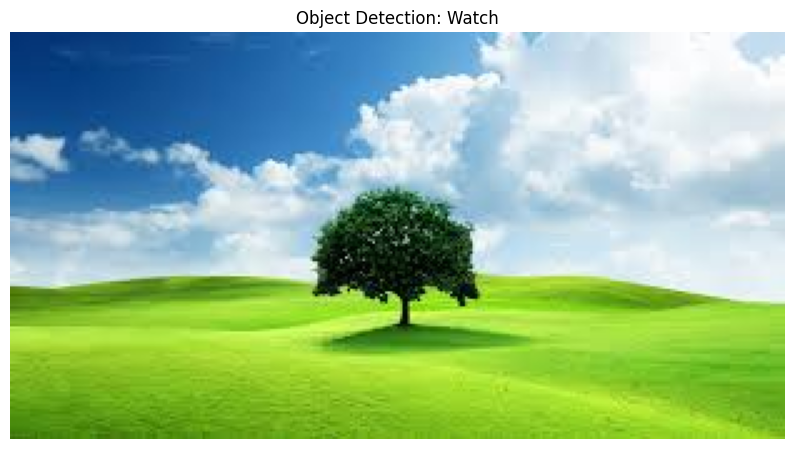

In [2]:
!pip install ultralytics
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

# Step 1: Use the provided image 'image 3.jpg'
image_path = '/content/image 3.jpg'

# Step 2: Load a pre-trained YOLOv8 model
# We'll use the 'yolov8n' (nano) model, which is small and fast.
model = YOLO('yolov8n.pt')  # Loads a pre-trained YOLOv8n model

# Step 3: Load the image
image = cv2.imread(image_path)

if image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # OpenCV loads images in BGR format, convert to RGB for matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Step 4: Perform object detection
    # The 'conf' argument sets the confidence threshold for detections
    # The 'classes' argument allows filtering by specific class IDs.
    # For 'watch', we need to know its class ID in COCO dataset.
    # YOLOv8 models trained on COCO dataset have 'wristwatch' as class ID 63.
    # If the model detects 'watch' as a different class, this will need adjustment.
    results = model(image_rgb, conf=0.5, classes=63)  # Detect objects with confidence > 0.5, specifically 'wristwatch' (class 63)

    # Step 5: Process results and draw bounding boxes
    for r in results:
        boxes = r.boxes  # Bounding box objects
        for box in boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            confidence = box.conf[0]
            cls = int(box.cls[0])

            # Get class name
            class_name = model.names[cls]

            # Draw bounding box and label only if it's a 'wristwatch'
            if class_name == 'wristwatch':
                color = (0, 255, 0)  # Green color for bounding box
                thickness = 2
                cv2.rectangle(image_rgb, (x1, y1), (x2, y2), color, thickness)
                label = f'{class_name} {confidence:.2f}'
                cv2.putText(image_rgb, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, thickness)

    # Step 6: Display the result
    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title('Object Detection: Watch')
    plt.show()